# The Uncanny Valley
In this notebook we show how to find the uncanny valley and provide a minimal implementation.
We will use the utils from our codebase, however we will also explain what changes are required to use your own code base. <br>

The notebook is structure as follows: <br>
<ol start="0">
  <li>Train a model or download the one we use in this notebook here.</li>
  <li>Load the model</li>
  <li>Load Dataset</li>
  <li> Generate adversarial examples </li>
  <li> Compute the flatness measure on the path </li>
  <li> Plot the results</li>
</ol>


# 1. Load the model

**Changes for your code:** You can replace this cell with your specific loading procedure. 
The model must be a `nn.Module` with a `forward` function that maps images to logits.

In [1]:
import models, torch
import torch.nn as nn
import numpy as np
from utils.model import subnet_to_dense
from demo_utils import *

device = "cuda"
model_type = "resnet-eps-0"
arch, path = model_path_dict[model_type]
model = models.__dict__[arch](nn.Conv2d, nn.Linear, "kaiming_normal", num_classes=10).to(device)
checkpoint = torch.load(path, map_location=device)
checkpoint["state_dict"] = subnet_to_dense(checkpoint["state_dict"],1.0) # Legacy from the initial codebase
model.load_state_dict(checkpoint["state_dict"])

<All keys matched successfully>

# 2. Load Dataset

In [2]:
from data.cifar import CIFAR10

data_dir = "./datasets"
test_batch_size = 1024
_, test_loader = CIFAR10(data_dir=data_dir, test_batch_size=test_batch_size).data_loaders()

Files already downloaded and verified
Files already downloaded and verified
Traing loader: 50000 images, Test loader: 10000 images


# 3. Generate Adversarial Examples
Currently, the codebase supports to conduct attacks with PGD and C&W. For PGD, you can change the paramerers in line 3.

In [3]:
from demo_utils import AttackArgs, attack_model

args = AttackArgs(delta=8/255, num_steps=10) # these parameters are only for pgd
path, targets = attack_model(model, test_loader, "pgd", args, device="cuda")

Test: [ 9/10] Time  0.097 ( 0.140) Loss 0.2845 (0.2841) Acc_1  94.77 ( 93.88) Acc_5  99.87 ( 99.78)
Test: [ 9/10] Time  0.818 ( 1.048) Loss 0.2845 (0.2841) Adv_Loss 29.8838 (29.9629) Acc_1  94.77 ( 93.88) Acc_5  99.87 ( 99.78) Adv-Acc_1   0.00 (  0.01) Adv-Acc_5   8.55 (  6.84)


# 4. Compute sharpness

In [4]:
from torch.utils.data import DataLoader
from utils.eval import accuracy
from utils.logging import AverageMeter
from models.resnet_cifar import ResNet
from models.vgg_cifar import VGG
from models.wrn_cifar import WideResNet
from demo_utils import plot_sharpnes_loss
import torchvision
from tqdm import tqdm
import sys

train = torch.utils.data.TensorDataset(path, targets)
adv_loader = DataLoader(train, batch_size=1, shuffle=False)

**Changes for your model**: 
1. The `forward` function must also take an argument `ret_act` to also return the activations
of the penultimate layer i.e. the embedding for the feed forward layer (line 24, in the second cell below). 
2. A getter to have acces to the weight matrix of the final fullc connected layer. This can also be just a variable access (line 38 below).

In [5]:
max_iterations = 1000

criterion = nn.CrossEntropyLoss()
batch_time = AverageMeter("Time", ":6.3f")
losses = AverageMeter("Loss", ":.4f")
top1 = AverageMeter("Acc_1", ":6.2f")
top5 = AverageMeter("Acc_5", ":6.2f")
fam = AverageMeter("Acc_5", ":6.2f")

all_sharpness = []
norms = []
hessians = []
losses = []

model.eval()
for i, data in tqdm(enumerate(adv_loader), total=max_iterations, ncols= 100):
    trace_images, target = data[0][0].to(device), data[1].to(device)
    trace_sharpness = []
    trace_loss = []
    if i > max_iterations:
        break
    for j in range(trace_images.shape[0]):
        image = trace_images[j]
        output, phi = model(image, ret_act=True)

        probs = torch.softmax(output,dim=1)
        hessian = (probs*(1-probs)).sum() * (phi*phi).sum()
        
        if isinstance(model, torchvision.models.densenet.DenseNet):
            weights_norm = torch.linalg.norm(model.classifier.weight)
        elif isinstance(model, ResNet):
            weights_norm = torch.linalg.norm(model.linear.weight)
        elif isinstance(model, VGG):
            weights_norm = torch.linalg.norm(model.classifier[4].weight)
        elif isinstance(model, WideResNet):
            weights_norm = torch.linalg.norm(model.fc.weight)
        else:
            # Here your code to extract the weight of the final fc layer
            pass
            
        loss = criterion(output, target)
        sharpness = weights_norm * hessian
        acc1, acc5 = accuracy(output, target, topk=(1, 5))
        trace_sharpness.append(sharpness.detach().cpu())
        trace_loss.append(loss.detach().cpu())

    top1.update(acc1[0], image.size(0))
    top5.update(acc5[0], image.size(0))

    all_sharpness.append(trace_sharpness)
    losses.append(trace_loss)

all_sharpness = np.array(all_sharpness)
losses = np.array(losses)

1001it [00:29, 33.53it/s]                                                                           


# 5. Plot the resulst

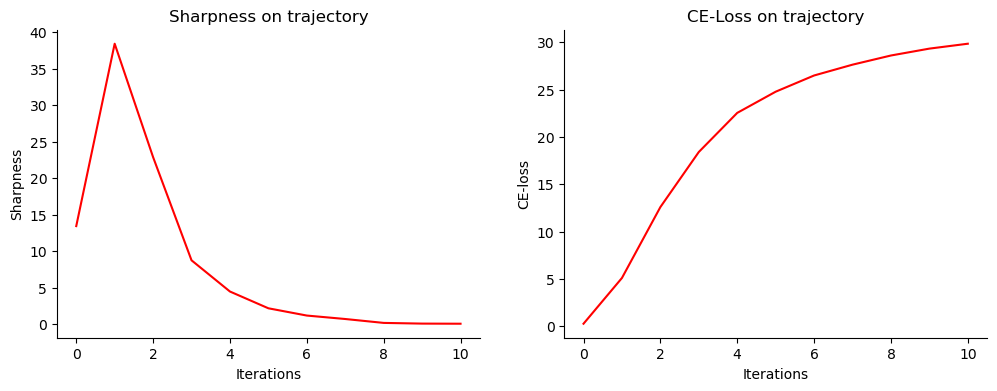

In [6]:
plot_sharpnes_loss(all_sharpness, losses)